In [1]:
import numpy as np
from scipy import signal
# from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (5,4)
plt.rc('font', size = 12) 

import os
import sys
repo_root = os.path.abspath(".")
sys.path.insert(0, os.path.join(repo_root, "src"))
sys.path.insert(0, repo_root)


import TJ_orbit
import TJ_gw
import TJ_ob
import TJ_lock
import TJ_synthesis
import TJ_tdi

In [2]:
tstart= 0.0*3e7
tstop = tstart + 40000.
orbits = TJ_orbit.orbit(t_start=tstart,t_end=tstop,tri_arm=3e6/(3e5),orbit_type='heliocentric')

In [3]:
# Option 1: Single GW source (traditional)
# gws = TJ_gw.gw(orbits, t_start=tstart, t_end=tstop, fsample=0.05, fgw=0.007, strain=1e-23, hasGW=True)

# Option 2: Multiple GW sources with different sky directions
sources = [
#     {'fgw': 0.002, 'strain': 1e-23, 'beta': 0, 'lamda': 0, 'psi': 0},                      # Source 1: Ecliptic plane
#     {'fgw': 0.005, 'strain': 2e-23, 'beta': np.pi/3, 'lamda': np.pi/2, 'psi': np.pi/4},    # Source 2: Northern sky
     {'fgw': 0.007, 'strain': 1e-25, 'beta': -np.pi/4, 'lamda': np.pi, 'psi': np.pi/3}      # Source 3: Southern sky
 ]
gws = TJ_gw.gw(orbits, t_start=tstart, t_end=tstop, fsample=0.1, source_list=sources, hasGW=True)

# Option 3: Frequency series (30 sources from 1e-4 to 0.1 Hz, log-spaced)
# freq_array = np.logspace(np.log10(1e-4), np.log10(0.1), 30)  # 30 frequencies from 1e-4 to 0.1 Hz
# sources = [{'fgw': freq, 'strain': 1e-23, 'beta': 0, 'lamda': 0, 'psi': 0} for freq in freq_array]
# gws = TJ_gw.gw(orbits, t_start=tstart, t_end=tstop, fsample=0.1, source_list=sources, hasGW=True)

# print(f"Number of GW sources: {gws.n_sources}")
# print(f"Frequency range: {freq_array[0]:.2e} Hz to {freq_array[-1]:.2e} Hz")
# print(f"First 5 frequencies: {freq_array[:5]}")
# print(f"Last 5 frequencies: {freq_array[-5:]}")

In [4]:
d_level='1' # flexible arm length

# Old implementation (slow for large lists due to repeated memory reallocation):
# obs=[None]
# for ii in [1,2,3,4,5,6]:
#     obs.append(TJ_ob.ob(t_start=tstart,t_end=tstop,fsample = 10, hasLaser=True, hasAcc=False, hasOms=False))

# Optimized implementation (pre-allocate list):
# obs = [None] * 7, then assign indices 1-6 with ob objects
obs = [None] * 7  # Pre-allocate list: [None, None, None, None, None, None, None]

# Create optical bench objects for all 6 arms
# Indexing: obs[1], obs[2], obs[3] = forward arms; obs[-1], obs[-2], obs[-3] = reverse arms (equivalent to obs[6], obs[5], obs[4])
for ii in range(1, 7):
    obs[ii] = TJ_ob.ob(t_start=tstart, t_end=tstop, fsample=5, hasLaser=True, hasAcc=False, hasOms=False)

In [8]:
lk = TJ_lock.lock(orbits, obs, gws, lock_type='dual', arm1_delay=20.1, arm2_delay=19.9, gfactor=10000.0, afactor=100.0, w0=2*np.pi*0.4)
lk.run()

array([-1.93816986e-13,  1.41338779e-13,  5.85116219e-14, ...,
       -1.25880055e-13, -1.25877360e-13, -1.25881229e-13])

In [9]:
TJ_synthesis.synthesis(orbits, obs, gws, delay_level=d_level)

Synthesis optimization : Laser=✓, GW=✓, Acc=✗, OMS=✗


In [10]:
mytdi = TJ_tdi.tdi(orbits,obs)
myX1=mytdi.run(TDI_channel=TJ_tdi.X1,delay_level=d_level)
myX2=mytdi.run(TDI_channel=TJ_tdi.X2,delay_level=d_level)

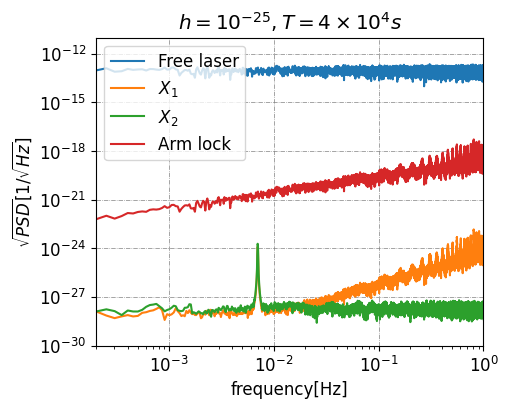

In [11]:
fphy = obs[-1]._fsample
laser_0 = obs[-1]._laser_noise
laser_1 = obs[-1]._laser
a_start = 100*fphy
b_end = - a_start 

num = 2
total_n = len(myX1[a_start:b_end])
freqs, psdl0 = signal.welch(laser_0[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdX1 = signal.welch(myX1[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdX2 = signal.welch(myX2[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdl1 = signal.welch(laser_1[a_start:b_end],fphy, nperseg=total_n/num)
plt.loglog(freqs,np.sqrt(psdl0),label="Free laser")
plt.loglog(freqs,np.sqrt(psdX1),label=r'$X_1$')
plt.loglog(freqs,np.sqrt(psdX2),label=r'$X_2$')
plt.loglog(freqs,np.sqrt(psdl1),label="Arm lock")
plt.legend()
plt.grid(color = 'gray', linestyle = '-.', linewidth = 0.5)
plt.rcParams["figure.figsize"] = (5,4)

plt.xlim([2e-4, 1])
plt.ylim([1e-30, 1e-11])
plt.xlabel('frequency[Hz]')
plt.ylabel(r'$\sqrt{PSD}[1/\sqrt{Hz}]$')
plt.title(r'$h = 10^{-25}, T=4\times10^{4}s$')
plt.show()

In [9]:
mya1=mytdi.run(TDI_channel=TJ_tdi.a1,delay_level=d_level)
mya2=mytdi.run(TDI_channel=TJ_tdi.a15,delay_level=d_level)

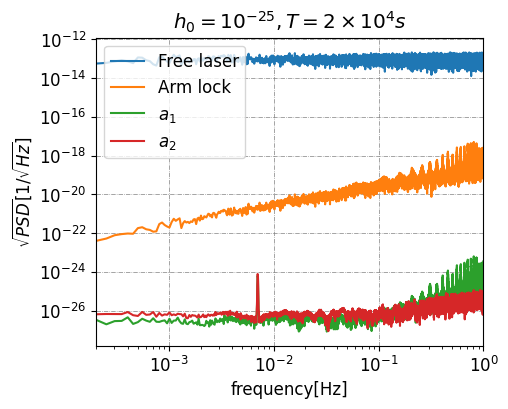

In [10]:
num = 2
total_n = len(mya1[a_start:b_end])
freqs, psdl0 = signal.welch(laser_0[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdl1 = signal.welch(laser_1[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psda1 = signal.welch(mya1[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psda2 = signal.welch(mya2[a_start:b_end],fphy, nperseg=total_n/num)
plt.loglog(freqs,np.sqrt(psdl0),label="Free laser")
plt.loglog(freqs,np.sqrt(psdl1),label="Arm lock")
plt.loglog(freqs,np.sqrt(psda1),label=r'$a_1$')
plt.loglog(freqs,np.sqrt(psda2),label=r'$a_2$')
plt.legend()
plt.grid(color = 'gray', linestyle = '-.', linewidth = 0.5)
plt.xlim([2e-4, 1])
plt.xlabel('frequency[Hz]')
plt.ylabel(r'$\sqrt{PSD}[1/\sqrt{Hz}]$')
plt.title(r'$h_0 = 10^{-25}, T=2\times10^{4}s$')
plt.show()

In [10]:
myz1=mytdi.run(TDI_channel=TJ_tdi.z1,delay_level=d_level)
myz2=mytdi.run(TDI_channel=TJ_tdi.z2,delay_level=d_level)

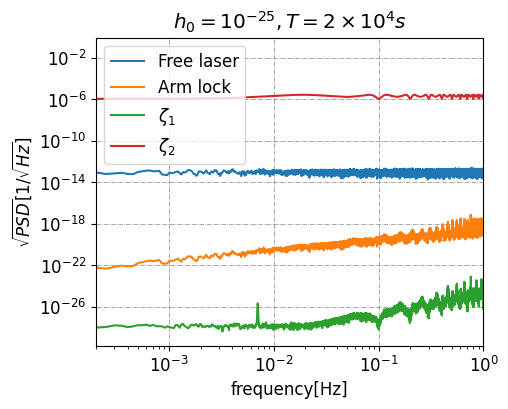

In [11]:
num = 2
total_n = len(myX1[a_start:b_end])
freqs, psdl0 = signal.welch(laser_0[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdl1 = signal.welch(laser_1[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdz1 = signal.welch(myz1[a_start:b_end],fphy, nperseg=total_n/num)
freqs, psdz2 = signal.welch(myz2[a_start:b_end],fphy, nperseg=total_n/num)
plt.loglog(freqs,np.sqrt(psdl0),label="Free laser")
plt.loglog(freqs,np.sqrt(psdl1),label="Arm lock")
plt.loglog(freqs,np.sqrt(psdz1),label=r'$\zeta_1$')
plt.loglog(freqs,np.sqrt(psdz2),label=r'$\zeta_2$')
plt.legend()
plt.grid(color = 'gray', linestyle = '-.', linewidth = 0.5)
plt.xlim([2e-4, 1])
plt.xlabel('frequency[Hz]')
plt.ylabel(r'$\sqrt{PSD}[1/\sqrt{Hz}]$')
plt.title(r'$h_0 = 10^{-25}, T=2\times10^{4}s$')
plt.show()

## Multi-Source Gravitational Wave Example

This section demonstrates the new multi-source GW capability with sources at different sky positions.

In [ ]:
# Create multiple GW sources with different sky directions
sources_multi = [
    {'fgw': 0.003, 'strain': 1e-23, 'beta': 0, 'lamda': 0, 'psi': 0},                      # Source 1: Ecliptic plane
    {'fgw': 0.007, 'strain': 8e-24, 'beta': np.pi/3, 'lamda': np.pi/2, 'psi': np.pi/4},    # Source 2: Northern sky
    {'fgw': 0.010, 'strain': 5e-24, 'beta': -np.pi/4, 'lamda': np.pi, 'psi': np.pi/3}      # Source 3: Southern sky
]

gws_multi = TJ_gw.gw(orbits, t_start=tstart, t_end=tstop, fsample=0.05, 
                     source_list=sources_multi, hasGW=True)

print(f"Number of GW sources: {gws_multi.n_sources}")
for i, src in enumerate(gws_multi.sources):
    print(f"  Source {i+1}: f={src['fgw']:.3f} Hz, h0={src['strain']:.2e}, "
          f"β={src['beta']:.2f} rad, λ={src['lamda']:.2f} rad")

In [ ]:
"""
# Visualize multi-source GW strain in arm 1
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Time series of GW strain in arm 1
t_plot = gws._tarray[:2000]  # First 2000 points for visualization
strain_arm1 = gws._gw_arr[0][:2000]

ax1.plot(t_plot, strain_arm1, linewidth=0.8)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('GW Strain')
ax1.set_title(f'GW Strain Time Series (Arm 1) - {gws.n_sources} Sources')
ax1.grid(True, alpha=0.3)

# Plot 2: PSD showing multiple frequency peaks
freqs_gw, psd_gw = signal.welch(gws._gw_arr[0], gws._fsample, nperseg=len(gws._gw_arr[0])//4)

ax2.loglog(freqs_gw, np.sqrt(psd_gw), linewidth=1.5, label='Total GW strain')

# Mark expected source frequencies
colors = ['red', 'green', 'blue']
for i, src in enumerate(gws.sources):
    ax2.axvline(src['fgw'], color=colors[i], linestyle='--', alpha=0.7, 
                label=f"f{i+1}={src['fgw']:.3f} Hz")

ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel(r'GW Strain PSD [1/$\sqrt{Hz}$]')
ax2.set_title('GW Strain PSD (Arm 1) - Multiple Frequency Components')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim([1e-4, 0.025])

plt.tight_layout()
plt.show()

print(f"GW strain statistics (Arm 1):")
print(f"  RMS: {np.std(gws._gw_arr[0]):.3e}")
print(f"  Max: {np.max(np.abs(gws._gw_arr[0])):.3e}")
"""

In [ ]:
# Dynesty inference demo (set RUN_DYNESTY_DEMO=True to execute)
RUN_DYNESTY_DEMO = False

if RUN_DYNESTY_DEMO:
    try:
        import dynesty  # noqa: F401
    except ImportError:
        print('dynesty not installed; run: python -m pip install dynesty')
    else:
        from utils.TJ_infer import InferenceConfig, Parameter, TriangleSimulator, run_dynesty

        config = InferenceConfig(
            channels=['X1'],
            fsample=1.0,
            t_start=0.0,
            t_end=2000.0,
            fsample_ob=1.0,
            fsample_gw=0.1,
            has_laser=False,
            has_acc=False,
            has_oms=False,
            apply_lock=False,
        )
        simulator = TriangleSimulator(config)

        true_params = {
            'fgw': 0.007,
            'strain': 1.0e-23,
            'beta': 0.0,
            'lamda': 0.0,
            'psi': 0.0,
        }
        model = simulator.simulate(true_params)['X1']
        rng = np.random.default_rng(0)
        data_y = model + 1.0e-22 * rng.standard_normal(model.shape)
        data = {
            't': np.linspace(config.t_start, config.t_end, len(data_y)),
            'y': {'X1': data_y},
        }

        params = [
            Parameter('fgw', prior='log_uniform', bounds=(1.0e-4, 1.0e-1)),
            Parameter('strain', prior='log_uniform', bounds=(1.0e-25, 1.0e-20)),
            Parameter('beta', prior='uniform', bounds=(-np.pi / 2, np.pi / 2)),
            Parameter('lamda', prior='uniform', bounds=(0.0, 2 * np.pi)),
            Parameter('psi', prior='uniform', bounds=(0.0, np.pi)),
            Parameter('acc', prior='log_uniform', bounds=(1.0e-16, 1.0e-12)),
            Parameter('oms', prior='log_uniform', bounds=(1.0e-16, 1.0e-12)),
        ]

        results = run_dynesty(
            data,
            params,
            config,
            dynesty_opts={
                'sampler': {'nlive': 100},
                'run': {'dlogz': 0.5},
            },
        )
        print('logZ:', results.logz[-1], 'logZerr:', results.logzerr[-1])
